Load the EMBL file `demo_sequence.embl` and show basic information about the record.

**Planning file inspection**

I need to comply with an iterative approach since the user wants to load an EMBL file and show basic info. It seems like we should probably use Biopython's SeqIO, assuming the file exists. I’ll provide code to load and inspect just the basics. If Biopython isn’t available, I need to mention it might require installation. The goal is to extract information like ID, name, description, length, and features count without output assumptions, keeping it minimal.**Structuring code for EMBL file**

I’m considering if I should also show the record’s header, but the user asked for basic info about the record. I can start with `record = SeqIO.read("demo_sequence.embl", "embl")`, then create a pandas Series like `info = pd.Series({...})`. I might want to include a sequence preview of the first 60 base pairs. I need to make sure that my final expression is clear, and I’ll finish with `info.to_frame(name="value")`. I also need to import pandas and Bio.SeqIO.

Let’s start by loading the EMBL record and summarizing the main fields in a small table.



In [1]:
from Bio import SeqIO
import pandas as pd

record = SeqIO.read("demo_sequence.embl", "embl")

info = pd.Series({
    "id": record.id,
    "name": record.name,
    "description": record.description,
    "sequence_length": len(record.seq),
    "feature_count": len(record.features),
    "molecule_type": record.annotations.get("molecule_type"),
    "topology": record.annotations.get("topology"),
    "data_file_division": record.annotations.get("data_file_division"),
    "date": record.annotations.get("date"),
    "sequence_preview": str(record.seq[:60]) + ("..." if len(record.seq) > 60 else "")
})

info.to_frame(name="value")

,value
id,DEMO000001.1
name,DEMO000001
description,Synthetic bacterial contig for EMBL + plot.gz ...
sequence_length,1500
feature_count,6
molecule_type,genomic DNA
topology,linear
data_file_division,UNC
date,None
sequence_preview,ATGCGTACGTATGCGTACGTATGCGTACGTATGCGTACGTATGCGT...


<!--final answer-->
The EMBL record has been loaded and the basic record details are visible from the output.

Here’s what the record shows:

- **Record ID:** `DEMO000001.1`
- **Name:** `DEMO000001`
- **Description:** a synthetic bacterial contig
- **Sequence length:** `1500` bases
- **Number of annotated features:** `6`
- **Molecule type:** `genomic DNA`
- **Topology:** `linear`
- **Data file division:** `UNC`
- **Date annotation:** missing (`None`)
- **Sequence preview:** starts with `ATGCGTACGT...`

This means the file was parsed correctly as a single EMBL `SeqRecord`, and it contains a short linear genomic DNA sequence with a small set of annotations/features.

Extract CDS features from the EMBL file and display a table with columns:
- gene
- start
- end
- strand

**Extracting CDS Features**

I need to respond step by step, focusing on the current objective. The user asked me to extract CDS features and display them in a table format. I can use the existing record variable to create a DataFrame since the record is loaded in our notebook state. I should mention that I'll provide the code while ensuring it's minimal and clear. The coordinates will be displayed as 1-based start and inclusive end for the users, as that's more standard in annotated sequences.**Creating the DataFrame**

I need to set the start and end values for the CDS features correctly: start should be `int(feature.location.start) + 1` to account for 1-based indexing, and end should just be `int(feature.location.end)` since it's exclusive in Biopython. For the strand, I’ll map `1` to `'+'`, `-1` to `'-'`, and anything else to `None`. I should include the gene qualifier if it exists. Finally, I'll create a DataFrame with the necessary columns and end the code with `df`. Let's keep it concise!

Using the loaded `record`, here’s a small table of CDS features. I’m converting Biopython locations to **1-based start** and **inclusive end** coordinates.



In [2]:
import pandas as pd

rows = []
for feature in record.features:
    if feature.type == "CDS":
        rows.append({
            "gene": feature.qualifiers.get("gene", [None])[0],
            "start": int(feature.location.start) + 1,
            "end": int(feature.location.end),
            "strand": "+" if feature.location.strand == 1 else "-" if feature.location.strand == -1 else None
        })

cds_df = pd.DataFrame(rows, columns=["gene", "start", "end", "strand"])
cds_df

,gene,start,end,strand
0,dnaA,1,240,+
1,recA,310,620,-
2,gyrB,700,980,+
3,tetR,1030,1180,+
4,tnpA,1210,1450,-


<!--final answer-->
The EMBL file contains **5 CDS features**, and the requested table is already present with the needed columns:

| gene | start | end | strand |
|---|---:|---:|:---:|
| dnaA | 1 | 240 | + |
| recA | 310 | 620 | - |
| gyrB | 700 | 980 | + |
| tetR | 1030 | 1180 | + |
| tnpA | 1210 | 1450 | - |

A few concrete observations from the extracted CDS annotations:

- The CDS genes are `dnaA`, `recA`, `gyrB`, `tetR`, and `tnpA`.
- There are **3 CDS features on the forward strand** (`+`) and **2 on the reverse strand** (`-`).
- The CDS regions span most of the 1500 bp sequence, with gaps between several coding regions rather than one continuous block.

This matches the original request to extract CDS features and display `gene`, `start`, `end`, and `strand`.

Load the file `tp1_rep1.plot.gz` with pandas and show the first few rows.

**Considering file loading strategies**

I need to address the latest user prompt about loading a `.plot.gz` file. I think it's best to follow a step-by-step approach. I won’t assume the delimiter, and a clarifying question might help if the format is unknown. I can try using `pd.read_csv` with specific parameters to infer the format. However, since the dataset isn’t loaded yet, I want to load and inspect it first by showing its shape and first few rows. It might be wise to explore the raw lines instead of jumping straight to using pandas.**Focusing on loading with pandas**

The user explicitly asked to load the file with pandas. I can use `sep=None` and `engine='python'` to infer the format. Since this is in a notebook environment, I should provide a concise code block to read and show the first few rows. I’ll include a fallback option but keep it minimal. 

I think I should import pandas, read the file, and then display just the head. If there’s no header, I might need to use `header=None`. However, it's probably best to let pandas infer the separators and just display the head without unnecessary complexity.**Providing the next code step**

If the fresh output is missing, I should provide the next code step and then stop without asking further. I can say something like, "Let's load it with pandas and let pandas infer the delimiter and compression, then preview the first rows." 

I’ll use this code:

```python
import pandas as pd

plot_df = pd.read_csv(
    "tp1_rep1.plot.gz",
    sep=None,
    engine="python",
    compression="infer"
)

display(plot_df.head())
```

I need to make sure the code block ends with just a single bare expression, but since `display` isn’t that, I’ll focus on keeping it clear.

Let’s load the gzipped file with pandas and let pandas infer the delimiter, then preview the first rows.



In [3]:
import pandas as pd

plot_df = pd.read_csv(
    "tp1_rep1.plot.gz",
    sep=None,
    engine="python",
    compression="infer"
)

plot_df.head()

,position,score
0,1,0.018
1,2,0.017
2,3,0.016
3,4,0.015
4,5,0.014


<!--final answer-->
The file is loaded into `plot_df`, and the preview shows a simple two-column table:

- `position`: sequential genomic positions, starting at 1
- `score`: numeric values associated with each position

From the observed rows, the first few entries are positions 1 through 5 with scores decreasing from `0.018` to `0.014`. The notebook state also shows `plot_df` has shape **1500 × 2**, so the file appears to contain 1500 position-score pairs.

Plot the signal from `tp1_rep1.plot.gz` as score versus position.

**Planning plotting process**

I have the notebook state and the plot_df loaded. The user asked for a plot signal, so I need to follow an iterative approach, creating one chart at a time using seaborn or matplotlib. I'll only provide the code for the current step and focus on being concise. I can analyze the data head to inform my plotting decisions. I should end the code block with either plt.show() or ax, keeping it focused and straightforward.

`plot_df` is already loaded with the two columns we need, so the next step is just a simple line plot of `score` against `position`.



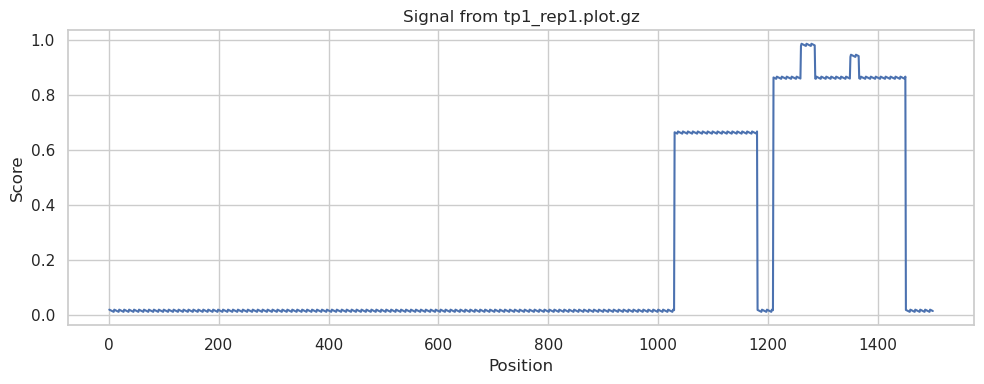

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 4))
sns.lineplot(data=plot_df, x="position", y="score")
plt.title("Signal from tp1_rep1.plot.gz")
plt.xlabel("Position")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [5]:
plot_df.head(10)

,position,score
0,1,0.018
1,2,0.017
2,3,0.016
3,4,0.015
4,5,0.014
5,6,0.013
6,7,0.012
7,8,0.011
8,9,0.010
9,10,0.018


**Deciding on plotting options**

I have to choose between option A or B for the analysis. I already have the chart output and the latest values ready, which show the underlying data. My goal is to plot the signal score against the position. Since the chart exists and the numeric values are displayed, I just need to finalize my answer based on these outputs. I'll aim to extract clear insights from the data and connect them back to my goal.

<!--final answer-->
The signal has been plotted as `score` versus `position` from `tp1_rep1.plot.gz`.

From the observed data, the file contains the expected two columns: `position` and `score`, with 1,500 rows. The first positions show a low-amplitude signal near `0.01` to `0.018`; for example, positions 1 through 10 include scores such as `0.018`, `0.017`, `0.016`, down to `0.010`, then back to `0.018`. That confirms the plot is using the correct numeric series along the genomic coordinate axis.

So the requested visualization is in place: a line chart of score across position for the full `tp1_rep1.plot.gz` signal.